# 1. Попередня обробка даних — Adult Census Income

**Мета:** Підготувати дані для пошуку асоціативних правил та кластеризації.

**Обрані атрибути (5):**
- **age** — вік (17–90). 74 унікальних значення.
- **education-num** — рівень освіти (1–16). Ординальна шкала: 1=Preschool, 9=HS-grad, 13=Bachelors, 16=Doctorate.
- **hours-per-week** — робочі години/тиждень (1–99). 96 унікальних значень.
- **marital-status** — сімейний стан (7 категорій). Сильно впливає на дохід.
- **occupation** — професія (14 категорій). Визначає рівень зайнятості та доходу.

**Чому саме ці:** всі мають багато значень (не бінарні!), дають 10 можливих пар для асоціативних правил. З них оберемо 4 пари з найвищим lift.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

data = fetch_openml(name="adult", version=2, as_frame=True, parser="auto")
df = data.frame
print(f"Завантажено: {df.shape[0]} рядків, {df.shape[1]} стовпців")
df.head()

Завантажено: 48842 рядків, 15 стовпців


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


## 1.1 Відбір та очищення

In [2]:
cols = ['age', 'education-num', 'hours-per-week', 'marital-status', 'occupation']
df = df[cols].copy()

print("Пропущені значення:")
print(df.isnull().sum())
df = df.dropna()
print(f"\nПісля видалення пропусків: {len(df)}")

dupes = df.duplicated().sum()
print(f"Дублікатів: {dupes}")
df = df.drop_duplicates()
print(f"Після видалення: {len(df)}")

for col in cols:
    print(f"\n{col}: {df[col].nunique()} унікальних значень")
df.describe(include='all')

Пропущені значення:
age                  0
education-num        0
hours-per-week       0
marital-status       0
occupation        2809
dtype: int64

Після видалення пропусків: 46033
Дублікатів: 19977
Після видалення: 26056

age: 74 унікальних значень

education-num: 16 унікальних значень

hours-per-week: 96 унікальних значень

marital-status: 7 унікальних значень

occupation: 14 унікальних значень


,age,education-num,hours-per-week,marital-status,occupation
count,26056.000000,26056.000000,26056.000000,26056,26056
unique,NaN,NaN,NaN,7,14
top,NaN,NaN,NaN,Married-civ-spouse,Prof-specialty
freq,NaN,NaN,NaN,11282,3412
mean,40.632522,9.952986,41.368629,NaN,NaN
std,14.000428,2.846400,14.307633,NaN,NaN
min,17.000000,1.000000,1.000000,NaN,NaN
25%,30.000000,9.000000,35.000000,NaN,NaN
50%,39.000000,10.000000,40.000000,NaN,NaN
75%,50.000000,12.000000,50.000000,NaN,NaN


## 1.2 Аналіз викидів

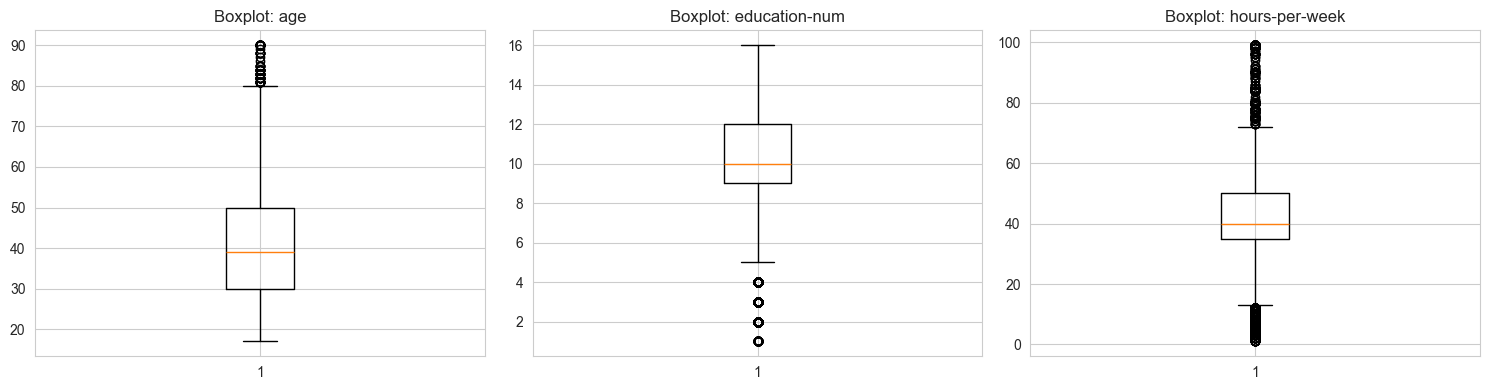

age: 115 викидів (0.4%) — не видаляємо, реальні дані
hours-per-week: 1459 викидів (5.6%) — не видаляємо, реальні дані


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['age', 'education-num', 'hours-per-week']):
    axes[i].boxplot(df[col].values)
    axes[i].set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

for col in ['age', 'hours-per-week']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col}: {outliers} викидів ({outliers/len(df)*100:.1f}%) — не видаляємо, реальні дані")

## 1.3 Розподіл атрибутів

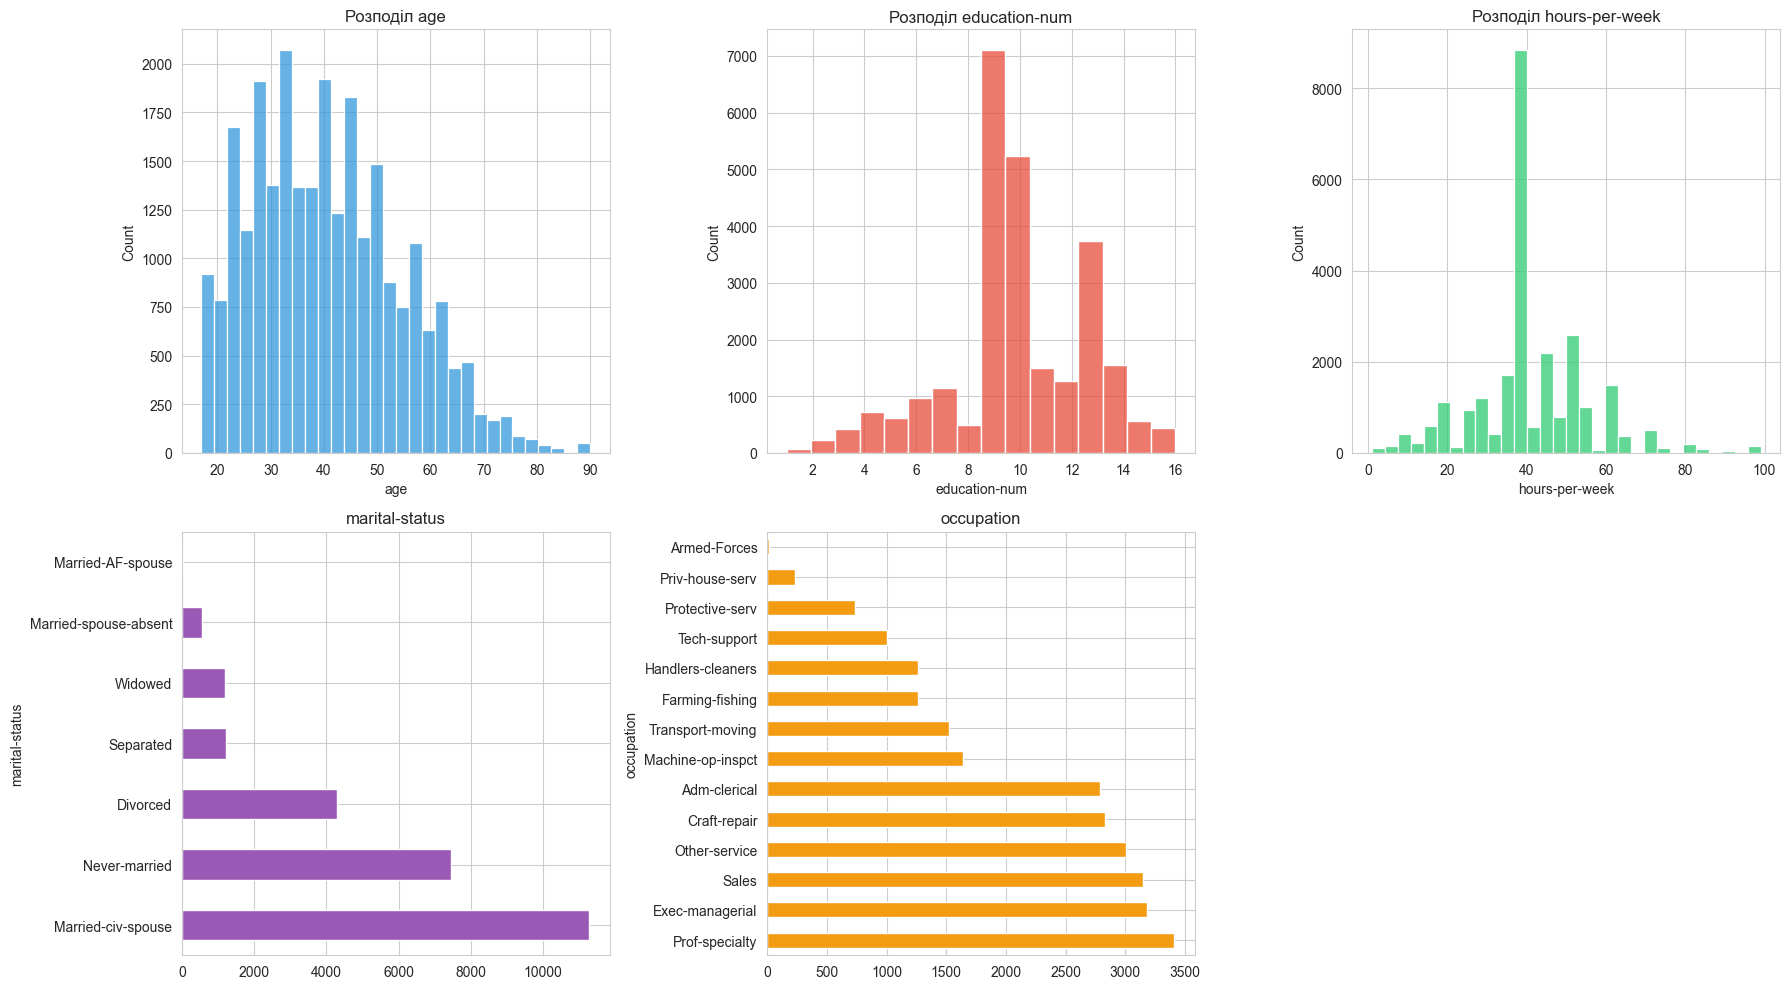

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(df['age'], bins=30, ax=axes[0,0], color='#3498db')
axes[0,0].set_title('Розподіл age')

sns.histplot(df['education-num'], bins=16, ax=axes[0,1], color='#e74c3c')
axes[0,1].set_title('Розподіл education-num')

sns.histplot(df['hours-per-week'], bins=30, ax=axes[0,2], color='#2ecc71')
axes[0,2].set_title('Розподіл hours-per-week')

df['marital-status'].value_counts().plot.barh(ax=axes[1,0], color='#9b59b6')
axes[1,0].set_title('marital-status')

df['occupation'].value_counts().plot.barh(ax=axes[1,1], color='#f39c12')
axes[1,1].set_title('occupation')

axes[1,2].axis('off')
plt.tight_layout()
plt.show()

## 1.4 Кореляційний аналіз

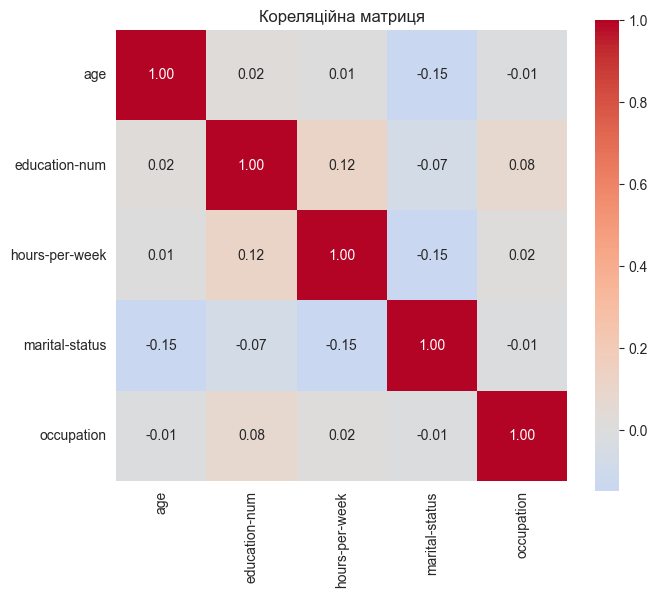

Більшість пар слабко корелюють — кожен атрибут несе унікальну інформацію


In [5]:
df_corr = df.copy()
for col in ['marital-status', 'occupation']:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

plt.figure(figsize=(7, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Кореляційна матриця')
plt.tight_layout()
plt.show()
print("Більшість пар слабко корелюють — кожен атрибут несе унікальну інформацію")

## 1.5 Кодування та дискретизація

In [6]:
# === Числова версія для кластеризації ===
df_num = df.copy()
le_marital = LabelEncoder().fit(df_num['marital-status'])
le_occup = LabelEncoder().fit(df_num['occupation'])
df_num['marital-status'] = le_marital.transform(df_num['marital-status'])
df_num['occupation'] = le_occup.transform(df_num['occupation'])

print("Кодування marital-status:")
for i, c in enumerate(le_marital.classes_): print(f"  {i} = {c}")
print("\nКодування occupation:")
for i, c in enumerate(le_occup.classes_): print(f"  {i} = {c}")

df_num.to_csv('data_processed.csv', index=False)

# === Дискретизована версія для Apriori ===
df_bin = df.copy()
df_bin['age'] = pd.cut(df['age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle', 'Senior'])
df_bin['education-num'] = pd.cut(df['education-num'], bins=[0, 8, 10, 13, 16],
                                  labels=['Edu_Low', 'Edu_Medium', 'Edu_High', 'Edu_VeryHigh'])
df_bin['hours-per-week'] = pd.cut(df['hours-per-week'], bins=[0, 35, 45, 100],
                                   labels=['PartTime', 'FullTime', 'Overtime'])
df_bin['marital-status'] = 'Mar_' + df_bin['marital-status'].astype(str)
df_bin['occupation'] = 'Occ_' + df_bin['occupation'].astype(str)
df_bin.to_csv('data_binned.csv', index=False)

# === Нормалізована версія для кластеризації ===
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_num), columns=df_num.columns)
df_scaled.to_csv('data_scaled.csv', index=False)

print(f"\nЗбережено: data_processed.csv, data_binned.csv, data_scaled.csv")
print(f"Рядків: {len(df_num)}")

Кодування marital-status:
  0 = Divorced
  1 = Married-AF-spouse
  2 = Married-civ-spouse
  3 = Married-spouse-absent
  4 = Never-married
  5 = Separated
  6 = Widowed

Кодування occupation:
  0 = Adm-clerical
  1 = Armed-Forces
  2 = Craft-repair
  3 = Exec-managerial
  4 = Farming-fishing
  5 = Handlers-cleaners
  6 = Machine-op-inspct
  7 = Other-service
  8 = Priv-house-serv
  9 = Prof-specialty
  10 = Protective-serv
  11 = Sales
  12 = Tech-support
  13 = Transport-moving



Збережено: data_processed.csv, data_binned.csv, data_scaled.csv
Рядків: 26056


In [7]:
print("\nДискретизовані дані (для Apriori):")
for col in df_bin.columns:
    print(f"  {col}: {sorted(df_bin[col].unique())}")
df_bin.head(10)


Дискретизовані дані (для Apriori):
  age: ['Middle', 'Senior', 'Young']
  education-num: ['Edu_High', 'Edu_Low', 'Edu_Medium', 'Edu_VeryHigh']
  hours-per-week: ['FullTime', 'Overtime', 'PartTime']
  marital-status: ['Mar_Divorced', 'Mar_Married-AF-spouse', 'Mar_Married-civ-spouse', 'Mar_Married-spouse-absent', 'Mar_Never-married', 'Mar_Separated', 'Mar_Widowed']
  occupation: ['Occ_Adm-clerical', 'Occ_Armed-Forces', 'Occ_Craft-repair', 'Occ_Exec-managerial', 'Occ_Farming-fishing', 'Occ_Handlers-cleaners', 'Occ_Machine-op-inspct', 'Occ_Other-service', 'Occ_Priv-house-serv', 'Occ_Prof-specialty', 'Occ_Protective-serv', 'Occ_Sales', 'Occ_Tech-support', 'Occ_Transport-moving']


,age,education-num,hours-per-week,marital-status,occupation
0,Young,Edu_Low,FullTime,Mar_Never-married,Occ_Machine-op-inspct
1,Middle,Edu_Medium,Overtime,Mar_Married-civ-spouse,Occ_Farming-fishing
2,Young,Edu_High,FullTime,Mar_Married-civ-spouse,Occ_Protective-serv
3,Middle,Edu_Medium,FullTime,Mar_Married-civ-spouse,Occ_Machine-op-inspct
5,Middle,Edu_Low,PartTime,Mar_Never-married,Occ_Other-service
7,Senior,Edu_VeryHigh,PartTime,Mar_Married-civ-spouse,Occ_Prof-specialty
8,Young,Edu_Medium,FullTime,Mar_Never-married,Occ_Other-service
9,Senior,Edu_Low,PartTime,Mar_Married-civ-spouse,Occ_Craft-repair
10,Senior,Edu_Medium,FullTime,Mar_Married-civ-spouse,Occ_Machine-op-inspct
11,Middle,Edu_High,FullTime,Mar_Married-civ-spouse,Occ_Adm-clerical


## Підсумок

1. **5 атрибутів** з великою кількістю значень: age (74), education-num (16), hours-per-week (96), marital-status (7), occupation (14)
2. **10 можливих пар** — з них Apriori обере 4 з найвищим lift
3. **3 версії даних:** числова, дискретизована, нормалізована